# 🎯 Karisma AI — Model 1: Skill Extractor

**Capstone Project CC26-PSU202**

## Arsitektur & Strategi

Model ini bertugas mengekstrak skill dari raw text CV (bahasa Inggris).

**Pendekatan: Hybrid — DistilBERT Fine-tuned + Custom Callback**

| Komponen | Detail |
|---|---|
| Base Model | `distilbert-base-uncased` (pre-trained, di-fine-tune) |
| Task | Token Classification / NER (BIO tagging) |
| Label | B-SKILL, I-SKILL, O |
| Custom Component | `SkillExtractionCallback` (Custom Callback) |
| Dataset | `glints_nlp_ready.csv` → skill vocabulary → synthetic CV sentences |
| Output | Model `.keras` / SavedModel siap produksi |

**Kenapa Synthetic Sentences?**
> Dataset Glints berisi daftar skill per job posting, bukan kalimat CV. Kita generate synthetic CV sentences menggunakan template realistis, lalu label skill-nya secara otomatis dengan BIO tagging. Ini pendekatan yang umum digunakan di industri (weak supervision / programmatic labeling).

**Alur Inference (Production):**
```
PDF CV → raw text → Model 1 → ['python', 'sql', 'machine learning'] → Model 2 → Top 3 Careers
```

## 📦 Cell 1 — Install Dependencies

In [ ]:
!pip install transformers==4.44.0 --quiet
!pip install tensorflow-hub --quiet
!pip install seqeval

import os
print('✅ Dependencies installed')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=691a16c8ba8fdbc07e266093aeb85a5827239821aff391a7dafcb3d1c2f4df98
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval
✅ Dependencies installed


## 📂 Cell 2 — Mount Google Drive & Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# ⚠️ Sesuaikan path ini dengan lokasi file di Google Drive kamu
DATASET_PATH = '/content/drive/MyDrive/karisma_ai/glints_nlp_ready.csv'

# Alternatif: download langsung dari link
# !gdown '1upqxeakKwAQVqiEM3liqQxPrVq0-5Vhu' -O glints_nlp_ready.csv
# DATASET_PATH = 'glints_nlp_ready.csv'

import pandas as pd
df = pd.read_csv(DATASET_PATH)
print(f'✅ Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head(3)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dataset loaded: 35,586 rows x 15 columns


,Job_Link,Title,title_clean,title_tokens,title_token_count,Skills,skills_list,skills_clean,skill_count,salary_avg,salary_normalized,has_salary,text_combined,text_word_count,text_char_count
0,https://glints.com/id/opportunities/jobs/26fd8...,Driver Taksi,driver taksi,"['driver', 'taksi']",2,"Customer Service, Communication Skills, Driving","['customer service', 'communication', 'driving']","customer service, communication, driving",3,6000000.0,0.342857,True,driver taksi customer service communication dr...,10,90
1,https://glints.com/id/opportunities/jobs/d75a7...,Supir Taxi Online (Unit dari PT),supir taxi online,"['supir', 'taxi', 'online']",3,"Driving, Driver Training, Customer Service","['driving', 'driver training', 'customer servi...","driving, driver training, customer service",3,5750000.0,0.328571,True,supir taxi online driving driver training cust...,13,99
2,https://glints.com/id/opportunities/jobs/8431f...,Crew Dapur,crew dapur,"['crew', 'dapur']",2,"Time Management, Home Cooking, Cook, Teamwork","['time management', 'home cooking', 'cook', 't...","time management, home cooking, cook, teamwork",4,200000.0,0.011429,True,crew dapur time management home cooking cook t...,14,96


## 🔧 Cell 3 — Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import ast
import re
import json
import random
from collections import Counter

import tensorflow as tf
from transformers import (
    DistilBertTokenizerFast,
    TFDistilBertModel,
    DistilBertConfig
)
from sklearn.model_selection import train_test_split
from seqeval.metrics import classification_report, f1_score, accuracy_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Check GPU
gpus = tf.config.list_physical_devices('GPU')
print(f'✅ TensorFlow {tf.__version__}')
print(f'🖥️  GPU available: {len(gpus) > 0} — {gpus}')

✅ TensorFlow 2.20.0
🖥️  GPU available: True — [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 🗂️ Cell 4 — EDA: Eksplorasi Dataset & Skill Vocabulary

📊 Total rows: 35,586
📊 Total skill mentions: 189,254
📊 Unique skills (raw): 7,088
📊 Skill vocabulary (freq >= 2): 2,694



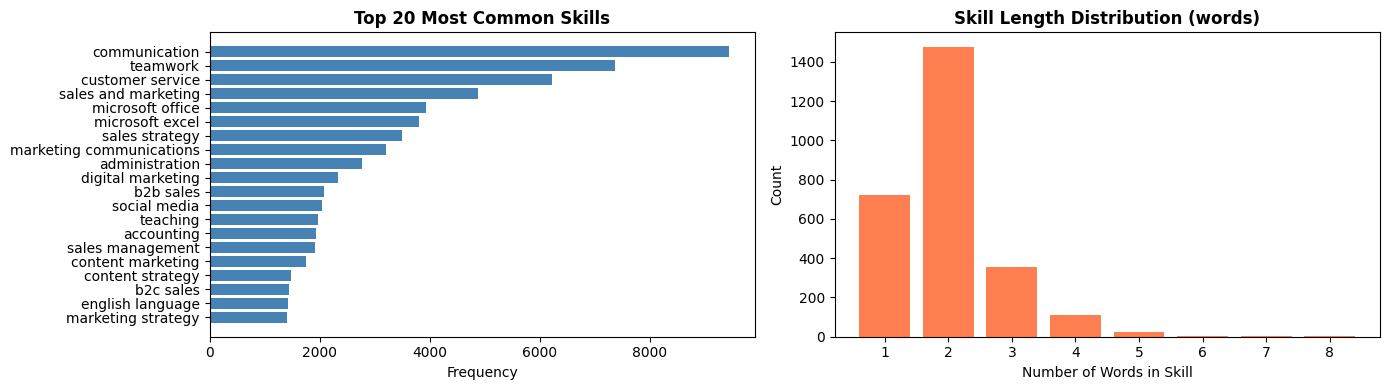

✅ EDA plots saved


In [ ]:
# ── Parse skills_list dari string ke Python list ──
def parse_skills(s):
    try:
        skills = ast.literal_eval(s)
        return [sk.lower().strip() for sk in skills if sk.strip()]
    except:
        return []

df['skills_parsed'] = df['skills_list'].apply(parse_skills)

# ── Build skill vocabulary ──
all_skills = []
for skills in df['skills_parsed']:
    all_skills.extend(skills)

skill_counter = Counter(all_skills)
# Filter: minimal muncul 2x untuk menghindari typo/noise
SKILL_VOCAB = sorted([skill for skill, count in skill_counter.items() if count >= 2])

print(f'📊 Total rows: {len(df):,}')
print(f'📊 Total skill mentions: {len(all_skills):,}')
print(f'📊 Unique skills (raw): {len(skill_counter):,}')
print(f'📊 Skill vocabulary (freq >= 2): {len(SKILL_VOCAB):,}')
print()

# ── Visualisasi distribusi ──
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Top 20 skills
top20 = pd.Series(all_skills).value_counts().head(20)
axes[0].barh(top20.index[::-1], top20.values[::-1], color='steelblue')
axes[0].set_title('Top 20 Most Common Skills', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Frequency')

# Distribusi panjang skill (jumlah kata)
skill_lengths = [len(s.split()) for s in SKILL_VOCAB]
length_dist = Counter(skill_lengths)
axes[1].bar(length_dist.keys(), length_dist.values(), color='coral')
axes[1].set_title('Skill Length Distribution (words)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Words in Skill')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('eda_skill_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ EDA plots saved')

## 🏗️ Cell 5 — Bangun Dataset Training: Synthetic CV Sentences + BIO Tagging

> **Strategi:** Karena dataset Glints adalah job posting (bukan CV), kita buat synthetic training sentences menggunakan template CV yang realistis. Skill dari vocabulary di-embed ke dalam kalimat, lalu di-tag dengan format BIO (B-SKILL, I-SKILL, O).
>
> Ini adalah teknik **weak supervision / programmatic labeling** yang umum di industri NLP.

In [ ]:
# ── Template kalimat CV bahasa Inggris yang realistis ──
CV_TEMPLATES = [
    "Proficient in {skill1} and {skill2} with hands-on experience.",
    "Strong background in {skill1}, {skill2}, and {skill3}.",
    "I have experience in {skill1} and solid knowledge of {skill2}.",
    "Skills include {skill1}, {skill2}, {skill3}, and {skill4}.",
    "Experienced professional with expertise in {skill1} and {skill2}.",
    "Developed and maintained projects using {skill1} and {skill2}.",
    "Responsible for {skill1}, {skill2}, and {skill3} in previous role.",
    "Technical skills: {skill1}, {skill2}, {skill3}.",
    "Key competencies: {skill1} and {skill2}.",
    "Worked with {skill1} to deliver results, also knowledgeable in {skill2}.",
    "Demonstrated ability in {skill1} and {skill2} throughout career.",
    "Core skills: {skill1}, {skill2}, {skill3}, and {skill4}.",
    "Used {skill1} daily. Also experienced in {skill2} and {skill3}.",
    "Certified in {skill1} with additional skills in {skill2}.",
    "Applied {skill1} and {skill2} to complete projects on time and budget.",
    "Volunteered and practiced {skill1}, improving proficiency in {skill2}.",
    "My technical toolkit includes {skill1}, {skill2}, and {skill3}.",
    "Fluent in {skill1} and comfortable working with {skill2}.",
    "Led teams using {skill1} methodology and managed {skill2} tools.",
    "Collaborated cross-functionally, utilizing {skill1} and {skill2} skills.",
]

# ── Fungsi generate sentence dari template ──
def fill_template(template, skill_vocab, rng):
    placeholders = re.findall(r'\{skill\d+\}', template)
    n_needed = len(placeholders)
    selected = rng.sample(skill_vocab, min(n_needed, len(skill_vocab)))
    filled = template
    for i, ph in enumerate(placeholders):
        filled = filled.replace(ph, selected[i], 1)
    return filled, selected

# ── BIO Tagger ──
def bio_tag_sentence(sentence, skills_in_sentence):
    """
    Tokenize by whitespace, lalu assign BIO tags.
    Returns: (tokens, tags)
    """
    # Sort by length descending agar multi-word skill diproses duluan
    skills_sorted = sorted(skills_in_sentence, key=lambda s: len(s.split()), reverse=True)

    tokens = sentence.split()
    tags = ['O'] * len(tokens)

    for skill in skills_sorted:
        skill_tokens = skill.split()
        n = len(skill_tokens)
        for i in range(len(tokens) - n + 1):
            window = [t.lower().strip('.,;:()"') for t in tokens[i:i+n]]
            if window == skill_tokens:
                # Cek belum di-tag
                if all(tags[i+j] == 'O' for j in range(n)):
                    tags[i] = 'B-SKILL'
                    for j in range(1, n):
                        tags[i+j] = 'I-SKILL'

    return tokens, tags

# ── Generate synthetic training data ──
rng = random.Random(SEED)

# Hanya gunakan skill yang berisi huruf latin (filter bahasa Indonesia/noise)
EN_SKILL_VOCAB = [
    s for s in SKILL_VOCAB
    if re.match(r'^[a-zA-Z0-9 .#+/&-]+$', s) and len(s) <= 40
]
print(f'English-compatible skills: {len(EN_SKILL_VOCAB):,}')

N_SAMPLES = 20000  # jumlah synthetic sentences

training_data = []  # list of (tokens, tags)

for _ in range(N_SAMPLES):
    template = rng.choice(CV_TEMPLATES)
    sentence, skills_used = fill_template(template, EN_SKILL_VOCAB, rng)
    tokens, tags = bio_tag_sentence(sentence, skills_used)
    training_data.append((tokens, tags))

# Verifikasi sampel
print(f'\n✅ Generated {len(training_data):,} synthetic sentences')
print('\nSample 1:')
toks, tgs = training_data[0]
for t, g in zip(toks, tgs):
    print(f'  {t:30s} → {g}')
print('\nSample 2:')
toks, tgs = training_data[1]
for t, g in zip(toks, tgs):
    print(f'  {t:30s} → {g}')

# Distribusi label
all_tags = [t for _, tags in training_data for t in tags]
tag_dist = Counter(all_tags)
print(f'\nLabel distribution:')
for tag, count in sorted(tag_dist.items()):
    pct = count / len(all_tags) * 100
    print(f'  {tag:10s}: {count:,} ({pct:.1f}%)')

English-compatible skills: 2,636

✅ Generated 20,000 synthetic sentences

Sample 1:
  Skills                         → O
  include                        → O
  analitik                       → B-SKILL
  data,                          → I-SKILL
  informatif,                    → B-SKILL
  hairstylist,                   → B-SKILL
  and                            → O
  furniture                      → B-SKILL
  care.                          → I-SKILL

Sample 2:
  Experienced                    → O
  professional                   → O
  with                           → O
  expertise                      → O
  in                             → O
  codeigniter                    → B-SKILL
  and                            → O
  software                       → B-SKILL
  requirements                   → I-SKILL
  analysis.                      → I-SKILL

Label distribution:
  B-SKILL   : 48,859 (23.7%)
  I-SKILL   : 46,077 (22.3%)
  O         : 111,470 (54.0%)


## 🏷️ Cell 6 — Tokenisasi dengan DistilBERT Tokenizer + Align BIO Labels

In [ ]:
# ── Load DistilBERT Tokenizer ──
MODEL_CHECKPOINT = 'distilbert-base-uncased'
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_CHECKPOINT)

# ── Label mapping ──
LABEL2ID = {'O': 0, 'B-SKILL': 1, 'I-SKILL': 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
NUM_LABELS = len(LABEL2ID)

print(f'Label mapping: {LABEL2ID}')

# ── Fungsi align labels ke subword tokens ──
def tokenize_and_align_labels(tokens, tags, max_length=128):
    """
    DistilBERT memecah kata jadi subwords (e.g., 'learning' → ['learn', '##ing']).
    Label harus di-align: subword pertama dapat label asli, sisanya dapat -100 (ignored).
    """
    encoding = tokenizer(
        tokens,
        is_split_into_words=True,
        truncation=True,
        padding='max_length',
        max_length=max_length,
        return_tensors=None
    )

    word_ids = encoding.word_ids()
    label_ids = []
    previous_word_idx = None

    for word_idx in word_ids:
        if word_idx is None:
            # Special tokens [CLS], [SEP], [PAD]
            label_ids.append(-100)
        elif word_idx != previous_word_idx:
            # Token pertama dari setiap kata
            label_ids.append(LABEL2ID[tags[word_idx]])
        else:
            # Subword lanjutan: gunakan label sama tapi bisa juga -100
            # Kita pakai label sama (I-SKILL jika B-SKILL) agar model belajar span
            current_label = tags[word_idx]
            if current_label == 'B-SKILL':
                label_ids.append(LABEL2ID['I-SKILL'])
            else:
                label_ids.append(LABEL2ID[current_label])
        previous_word_idx = word_idx

    return {
        'input_ids': encoding['input_ids'],
        'attention_mask': encoding['attention_mask'],
        'labels': label_ids
    }

# ── Proses semua data ──
print('Tokenizing training data...')
MAX_LENGTH = 128

encoded_data = []
for tokens, tags in training_data:
    encoded = tokenize_and_align_labels(tokens, tags, max_length=MAX_LENGTH)
    encoded_data.append(encoded)

# Convert ke numpy arrays
input_ids = np.array([d['input_ids'] for d in encoded_data])
attention_masks = np.array([d['attention_mask'] for d in encoded_data])
labels = np.array([d['labels'] for d in encoded_data])

print(f'✅ Tokenized {len(encoded_data):,} sentences')
print(f'   input_ids shape: {input_ids.shape}')
print(f'   attention_mask shape: {attention_masks.shape}')
print(f'   labels shape: {labels.shape}')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

Label mapping: {'O': 0, 'B-SKILL': 1, 'I-SKILL': 2}
Tokenizing training data...
✅ Tokenized 20,000 sentences
   input_ids shape: (20000, 128)
   attention_mask shape: (20000, 128)
   labels shape: (20000, 128)


## ✂️ Cell 7 — Train/Val/Test Split

In [ ]:
# ── Split: 80% train, 10% val, 10% test ──
indices = np.arange(len(input_ids))

idx_train, idx_temp = train_test_split(indices, test_size=0.2, random_state=SEED)
idx_val, idx_test = train_test_split(idx_temp, test_size=0.5, random_state=SEED)

X_train_ids = input_ids[idx_train]
X_train_masks = attention_masks[idx_train]
y_train = labels[idx_train]

X_val_ids = input_ids[idx_val]
X_val_masks = attention_masks[idx_val]
y_val = labels[idx_val]

X_test_ids = input_ids[idx_test]
X_test_masks = attention_masks[idx_test]
y_test = labels[idx_test]

print(f'Train set : {len(X_train_ids):,} samples')
print(f'Val set   : {len(X_val_ids):,} samples')
print(f'Test set  : {len(X_test_ids):,} samples')

Train set : 16,000 samples
Val set   : 2,000 samples
Test set  : 2,000 samples


## 🧠 Cell 8 — Bangun Model: DistilBERT Fine-tuned (TF Functional API)

> Ini memenuhi **Main Quest**: model dibangun dengan TF/Keras, menggunakan DistilBERT sebagai backbone (pre-trained + fine-tuned), dan disimpan dalam format `.keras`.

In [ ]:
from transformers import TFDistilBertModel

# ── Bangun model dengan Keras Functional API ──
def build_skill_extractor_model(model_checkpoint, num_labels, max_length=128):
    """
    Arsitektur:
    Input → DistilBERT (pre-trained backbone) → Dropout → Dense (token classifier)

    Menggunakan TF Functional API sesuai main quest.
    """
    # Input layers
    input_ids_layer = tf.keras.Input(
        shape=(max_length,), dtype=tf.int32, name='input_ids'
    )
    attention_mask_layer = tf.keras.Input(
        shape=(max_length,), dtype=tf.int32, name='attention_mask'
    )

    # DistilBERT backbone (pre-trained)
    distilbert = TFDistilBertModel.from_pretrained(
        model_checkpoint,
        output_hidden_states=False
    )

    # Forward pass melalui DistilBERT
    # output.last_hidden_state shape: (batch, seq_len, 768)
    bert_output = distilbert(
        input_ids=input_ids_layer,
        attention_mask=attention_mask_layer,
        training=False  # diubah ke True saat fine-tuning nanti via trainable
    )
    sequence_output = bert_output.last_hidden_state  # (batch, seq_len, 768)

    # Classification head
    dropout = tf.keras.layers.Dropout(0.1, name='classifier_dropout')(sequence_output)
    logits = tf.keras.layers.Dense(
        num_labels,
        kernel_initializer='glorot_uniform',
        name='classifier'
    )(dropout)  # (batch, seq_len, num_labels)

    model = tf.keras.Model(
        inputs=[input_ids_layer, attention_mask_layer],
        outputs=logits,
        name='karisma_skill_extractor'
    )

    return model, distilbert

model, distilbert_backbone = build_skill_extractor_model(
    MODEL_CHECKPOINT, NUM_LABELS, MAX_LENGTH
)

print('✅ Model built with TF Functional API')
model.summary()

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_transform.weight', 'vocab_layer_norm.weight', 'vocab_layer_norm.bias', 'vocab_transform.bias', 'vocab_projector.bias']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertModel for predictions without further training.


✅ Model built with TF Functional API
Model: "karisma_skill_extractor"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_ids (InputLayer)      [(None, 128)]                0         []                            
                                                                                                  
 attention_mask (InputLayer  [(None, 128)]                0         []                            
 )                                                                                                
                                                                                                  
 tf_distil_bert_model (TFDi  TFBaseModelOutput(last_hid   6636288   ['input_ids[0][0]',           
 stilBertModel)              den_state=(None, 128, 768)   0          'attention_mask[0][0]']      
                             , hidden_s

## 🎛️ Cell 9 — Custom Callback: SkillExtractionCallback

> Ini memenuhi **Main Quest**: implementasi Custom Callback.

In [ ]:
class SkillExtractionCallback(tf.keras.callbacks.Callback):
    """
    Custom Callback untuk Model 1 — Skill Extractor.

    Fungsi:
    1. Monitor val_loss dan simpan best model otomatis
    2. Early stopping jika val_loss tidak membaik
    3. Log ringkasan performa per epoch ke file JSON
    4. Tampilkan contoh prediksi skill setiap N epoch
    """

    def __init__(
        self,
        patience=3,
        min_delta=0.001,
        save_path='best_skill_extractor.keras',
        log_path='training_log.json',
        demo_texts=None,
        demo_every_n_epochs=2,
        target_val_loss=0.05
    ):
        super().__init__()
        self.patience = patience
        self.min_delta = min_delta
        self.save_path = save_path
        self.log_path = log_path
        self.demo_texts = demo_texts or [
            "Proficient in Python and machine learning with 3 years experience.",
            "Skills include data analysis, SQL, and project management."
        ]
        self.demo_every_n_epochs = demo_every_n_epochs
        self.target_val_loss = target_val_loss

        self.best_val_loss = float('inf')
        self.wait = 0
        self.training_log = []
        self.stopped_epoch = 0

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_loss = logs.get('val_loss', float('inf'))
        val_acc = logs.get('val_accuracy', 0)

        # ── 1. Simpan log ──
        epoch_log = {
            'epoch': epoch + 1,
            'loss': round(logs.get('loss', 0), 4),
            'accuracy': round(logs.get('accuracy', 0), 4),
            'val_loss': round(val_loss, 4),
            'val_accuracy': round(val_acc, 4)
        }
        self.training_log.append(epoch_log)
        with open(self.log_path, 'w') as f:
            json.dump(self.training_log, f, indent=2)

        # ── 2. Save best model ──
        if val_loss < self.best_val_loss - self.min_delta:
            print(f'\n   📉 val_loss improved {self.best_val_loss:.4f} → {val_loss:.4f}. Saving model...')
            self.best_val_loss = val_loss
            self.model.save(self.save_path)
            self.wait = 0
        else:
            self.wait += 1
            print(f'\n   ⚠️  val_loss tidak membaik ({self.wait}/{self.patience}). Best: {self.best_val_loss:.4f}')

        # ── 3. Early stopping ──
        if self.wait >= self.patience:
            self.stopped_epoch = epoch
            self.model.stop_training = True
            print(f'\n   🛑 Early stopping triggered at epoch {epoch + 1}.')
            print(f'   Best val_loss: {self.best_val_loss:.4f}')

        # ── 4. Demo prediksi ──
        if (epoch + 1) % self.demo_every_n_epochs == 0:
            print(f'\n   🔍 Demo Skill Extraction (Epoch {epoch + 1}):')
            self._demo_prediction()

        # ── 5. Notifikasi target tercapai ──
        if val_loss <= self.target_val_loss:
            print(f'\n   🎯 Target val_loss ({self.target_val_loss}) TERCAPAI!')

    def _demo_prediction(self):
        """Jalankan inference cepat pada demo texts untuk monitor kualitas."""
        for text in self.demo_texts[:2]:
            try:
                words = text.split()
                enc = tokenizer(
                    words, is_split_into_words=True,
                    return_tensors='tf', truncation=True,
                    padding='max_length', max_length=128
                )
                logits = self.model([
                    enc['input_ids'], enc['attention_mask']
                ], training=False)
                predictions = tf.argmax(logits, axis=-1).numpy()[0]
                word_ids = enc.word_ids()

                extracted = []
                current_skill = []
                prev_word_idx = None
                for i, wid in enumerate(word_ids):
                    if wid is None or wid == prev_word_idx:
                        continue
                    label = ID2LABEL[predictions[i]]
                    if label == 'B-SKILL':
                        if current_skill:
                            extracted.append(' '.join(current_skill))
                        current_skill = [words[wid].lower().strip('.,;:()"\' ')]
                    elif label == 'I-SKILL' and current_skill:
                        current_skill.append(words[wid].lower().strip('.,;:()"\' '))
                    else:
                        if current_skill:
                            extracted.append(' '.join(current_skill))
                        current_skill = []
                    prev_word_idx = wid
                if current_skill:
                    extracted.append(' '.join(current_skill))

                print(f'      Text: "{text[:60]}..."')
                print(f'      Skills found: {extracted}')
            except Exception as e:
                print(f'      Demo error: {e}')

    def on_train_end(self, logs=None):
        if self.stopped_epoch > 0:
            print(f'\n✅ Training selesai dengan early stopping pada epoch {self.stopped_epoch + 1}')
        else:
            print('\n✅ Training selesai (semua epoch)')
        print(f'📄 Training log disimpan ke: {self.log_path}')

print('✅ SkillExtractionCallback (Custom Callback) defined')

✅ SkillExtractionCallback (Custom Callback) defined


## ⚙️ Cell 10 — Compile & Training Setup

In [ ]:
# ── Fine-tuning strategy: unfreeze semua layer ──
# DistilBERT akan di-fine-tune bersama classification head
distilbert_backbone.trainable = True

# ── Custom loss: Sparse Categorical Crossentropy dengan masking -100 ──
# Label -100 (special tokens & padding) harus di-ignore
class MaskedSparseCategoricalCrossentropy(tf.keras.losses.Loss):
    """
    Custom Loss yang mengabaikan token dengan label -100.
    Ini diperlukan karena BIO tagging menggunakan -100 untuk padding & special tokens.
    """
    def __init__(self, ignore_index=-100, **kwargs):
        super().__init__(**kwargs)
        self.ignore_index = ignore_index
        self.loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(
            from_logits=True, reduction='none'
        )

    def call(self, y_true, y_pred):
        # Cast labels
        y_true = tf.cast(y_true, tf.int32)

        # Mask: True di mana label bukan -100
        mask = tf.not_equal(y_true, self.ignore_index)

        # Replace -100 dengan 0 untuk menghindari error di loss fn
        y_true_clean = tf.where(mask, y_true, tf.zeros_like(y_true))

        # Hitung loss
        losses = self.loss_fn(y_true_clean, y_pred)

        # Apply mask: hanya hitung loss pada token yang valid
        mask_float = tf.cast(mask, tf.float32)
        masked_losses = losses * mask_float

        # Mean over valid tokens
        return tf.reduce_sum(masked_losses) / (tf.reduce_sum(mask_float) + 1e-8)

    def get_config(self):
        config = super().get_config()
        config.update({'ignore_index': self.ignore_index})
        return config

# ── Custom Accuracy Metric dengan masking ──
class MaskedAccuracy(tf.keras.metrics.Metric):
    def __init__(self, ignore_index=-100, name='masked_accuracy', **kwargs):
        super().__init__(name=name, **kwargs)
        self.ignore_index = ignore_index
        self.correct = self.add_weight(name='correct', initializer='zeros')
        self.total = self.add_weight(name='total', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(y_true, tf.int32)
        mask = tf.not_equal(y_true, self.ignore_index)

        pred_ids = tf.argmax(y_pred, axis=-1, output_type=tf.int32)
        correct = tf.equal(y_true, pred_ids)
        correct_masked = tf.logical_and(correct, mask)

        self.correct.assign_add(tf.reduce_sum(tf.cast(correct_masked, tf.float32)))
        self.total.assign_add(tf.reduce_sum(tf.cast(mask, tf.float32)))

    def result(self):
        return self.correct / (self.total + 1e-8)

    def reset_state(self):
        self.correct.assign(0)
        self.total.assign(0)

# ── Learning rate schedule: warm-up + decay ──
BATCH_SIZE = 16
EPOCHS = 10
STEPS_PER_EPOCH = len(X_train_ids) // BATCH_SIZE
WARMUP_STEPS = STEPS_PER_EPOCH * 1  # 1 epoch warmup
TOTAL_STEPS = STEPS_PER_EPOCH * EPOCHS

lr_schedule = tf.keras.optimizers.schedules.PolynomialDecay(
    initial_learning_rate=5e-5,
    decay_steps=TOTAL_STEPS,
    end_learning_rate=1e-6
)

optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

# ── Compile ──
model.compile(
    optimizer=optimizer,
    loss=MaskedSparseCategoricalCrossentropy(name='masked_ce_loss'),
    metrics=[MaskedAccuracy(name='accuracy')]
)

print('✅ Model compiled')
print(f'   Batch size: {BATCH_SIZE}')
print(f'   Epochs: {EPOCHS}')
print(f'   Steps per epoch: {STEPS_PER_EPOCH}')
print(f'   Total parameters: {model.count_params():,}')

✅ Model compiled
   Batch size: 16
   Epochs: 10
   Steps per epoch: 1000
   Total parameters: 66,365,187


## 🚀 Cell 11 — Training

In [ ]:
# ── Buat tf.data.Dataset untuk efisiensi ──
def make_dataset(ids, masks, lbls, batch_size, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((
        {'input_ids': ids, 'attention_mask': masks},
        lbls
    ))
    if shuffle:
        ds = ds.shuffle(buffer_size=5000, seed=SEED)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(X_train_ids, X_train_masks, y_train, BATCH_SIZE, shuffle=True)
val_ds = make_dataset(X_val_ids, X_val_masks, y_val, BATCH_SIZE)
test_ds = make_dataset(X_test_ids, X_test_masks, y_test, BATCH_SIZE)

# ── Custom callback instance ──
demo_texts = [
    "I am proficient in Python, machine learning, and data analysis.",
    "Strong skills in SQL, Excel, and project management.",
    "Experience with React, Node.js, and REST API development."
]

skill_callback = SkillExtractionCallback(
    patience=3,
    min_delta=0.001,
    save_path='best_skill_extractor.keras',
    log_path='training_log.json',
    demo_texts=demo_texts,
    demo_every_n_epochs=2,
    target_val_loss=0.05
)

# TensorBoard callback (Side Quest)
tensorboard_callback = tf.keras.callbacks.TensorBoard(
    log_dir='./logs/model1_skill_extractor',
    histogram_freq=1,
    write_graph=True
)

print('🚀 Memulai training...')
print(f'   Train samples: {len(X_train_ids):,}')
print(f'   Val samples  : {len(X_val_ids):,}')
print()

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=[skill_callback, tensorboard_callback],
    verbose=1
)

print('\n✅ Training selesai!')

🚀 Memulai training...
   Train samples: 16,000
   Val samples  : 2,000

Epoch 1/10
1000/1000 [==============================] - ETA: 0s - loss: 0.0111 - accuracy: 0.9962
   📉 val_loss improved inf → 0.0004. Saving model...

   🎯 Target val_loss (0.05) TERCAPAI!
1000/1000 [==============================] - 262s 237ms/step - loss: 0.0111 - accuracy: 0.9962 - val_loss: 3.9460e-04 - val_accuracy: 0.9999
Epoch 2/10
1000/1000 [==============================] - ETA: 0s - loss: 0.0013 - accuracy: 0.9997
   ⚠️  val_loss tidak membaik (1/3). Best: 0.0004

   🔍 Demo Skill Extraction (Epoch 2):
      Text: "I am proficient in Python, machine learning, and data analys..."
      Skills found: ['python', 'machine learning', 'data analysis']
      Text: "Strong skills in SQL, Excel, and project management...."
      Skills found: ['sql', 'excel', 'project management']

   🎯 Target val_loss (0.05) TERCAPAI!
1000/1000 [==============================] - 227s 227ms/step - loss: 0.0013 - accuracy: 0.9997 -

## 📈 Cell 12 — Plot Training History

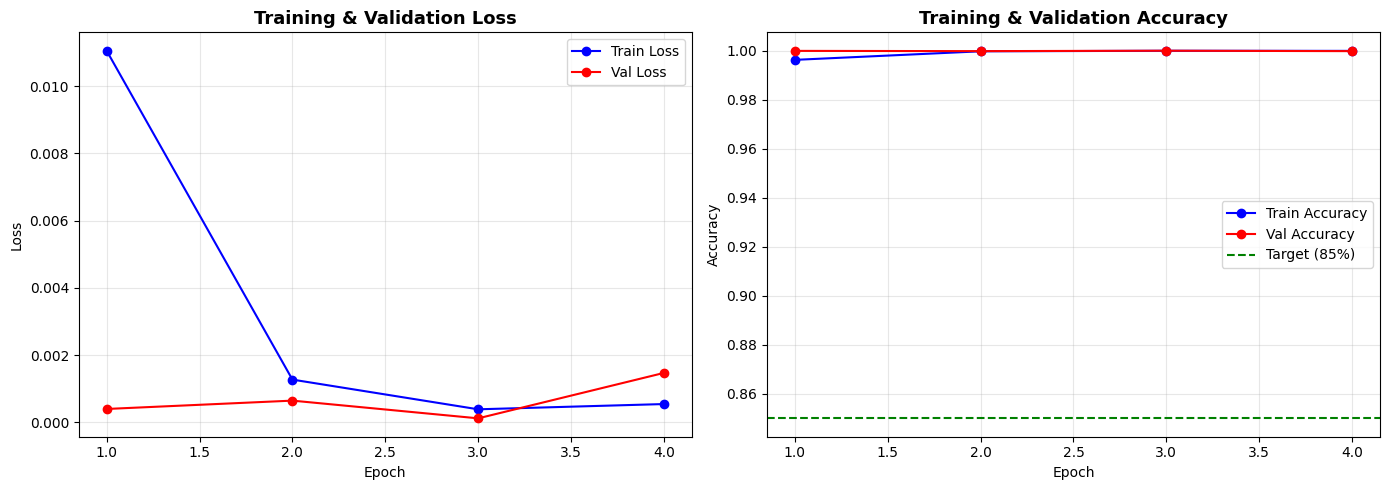

Best val_accuracy : 1.0000 (100.00%)
Best val_loss     : 0.0001
Target 85%        : ✅ TERCAPAI


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_ran = range(1, len(history.history['loss']) + 1)

# Loss plot
axes[0].plot(epochs_ran, history.history['loss'], 'b-o', label='Train Loss')
axes[0].plot(epochs_ran, history.history['val_loss'], 'r-o', label='Val Loss')
axes[0].set_title('Training & Validation Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(epochs_ran, history.history['accuracy'], 'b-o', label='Train Accuracy')
axes[1].plot(epochs_ran, history.history['val_accuracy'], 'r-o', label='Val Accuracy')
axes[1].axhline(y=0.85, color='green', linestyle='--', label='Target (85%)')
axes[1].set_title('Training & Validation Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=120, bbox_inches='tight')
plt.show()

best_val_acc = max(history.history['val_accuracy'])
best_val_loss = min(history.history['val_loss'])
print(f'Best val_accuracy : {best_val_acc:.4f} ({best_val_acc*100:.2f}%)')
print(f'Best val_loss     : {best_val_loss:.4f}')
print(f'Target 85%        : {"✅ TERCAPAI" if best_val_acc >= 0.85 else "❌ Belum tercapai"}')

## 📊 Cell 13 — Evaluasi Detail: seqeval F1 Score per Label

In [ ]:
# ── Load best model ──
print('Loading best model...')
best_model = tf.keras.models.load_model(
    'best_skill_extractor.keras',
    custom_objects={
        'MaskedSparseCategoricalCrossentropy': MaskedSparseCategoricalCrossentropy,
        'MaskedAccuracy': MaskedAccuracy,
        'TFDistilBertModel': TFDistilBertModel
    }
)

# ── Prediksi pada test set ──
print('Running predictions on test set...')
all_true_labels = []
all_pred_labels = []

for batch_x, batch_y in test_ds:
    logits = best_model(batch_x, training=False)
    predictions = tf.argmax(logits, axis=-1).numpy()
    true_labels = batch_y.numpy()

    for pred_seq, true_seq in zip(predictions, true_labels):
        pred_labels_row = []
        true_labels_row = []
        for p, t in zip(pred_seq, true_seq):
            if t == -100:
                continue  # skip special tokens & padding
            pred_labels_row.append(ID2LABEL[p])
            true_labels_row.append(ID2LABEL[t])
        all_pred_labels.append(pred_labels_row)
        all_true_labels.append(true_labels_row)

# ── seqeval report ──
print('\n' + '='*60)
print('CLASSIFICATION REPORT (seqeval — entity-level)')
print('='*60)
print(classification_report(all_true_labels, all_pred_labels))

f1 = f1_score(all_true_labels, all_pred_labels)
print(f'Entity-level F1 Score: {f1:.4f} ({f1*100:.2f}%)')

Loading best model...
Running predictions on test set...

CLASSIFICATION REPORT (seqeval — entity-level)
              precision    recall  f1-score   support

       SKILL       1.00      1.00      1.00      4862

   micro avg       1.00      1.00      1.00      4862
   macro avg       1.00      1.00      1.00      4862
weighted avg       1.00      1.00      1.00      4862

Entity-level F1 Score: 0.9997 (99.97%)


## 💾 Cell 14 — Simpan Model dalam Format Produksi (.keras)

In [ ]:
import os

# ── Simpan model .keras (main quest) ──
FINAL_MODEL_PATH = 'karisma_skill_extractor_v1.keras'
best_model.save(FINAL_MODEL_PATH)
print(f'✅ Model saved: {FINAL_MODEL_PATH}')
print(f'   File size: {os.path.getsize(FINAL_MODEL_PATH) / 1024 / 1024:.1f} MB')

# ── Simpan juga sebagai SavedModel (opsional, untuk serving) ──
SAVEDMODEL_PATH = 'karisma_skill_extractor_savedmodel'
best_model.save(SAVEDMODEL_PATH)
print(f'✅ SavedModel saved: {SAVEDMODEL_PATH}/')

# ── Simpan skill vocabulary (dibutuhkan saat inference) ──
vocab_data = {
    'skill_vocab': EN_SKILL_VOCAB,
    'label2id': LABEL2ID,
    'id2label': ID2LABEL,
    'model_checkpoint': MODEL_CHECKPOINT,
    'max_length': MAX_LENGTH,
    'total_skills': len(EN_SKILL_VOCAB)
}

with open('skill_vocab.json', 'w') as f:
    json.dump(vocab_data, f, indent=2)
print(f'✅ Skill vocabulary saved: skill_vocab.json ({len(EN_SKILL_VOCAB):,} skills)')

# ── Copy ke Google Drive ──
import shutil
DRIVE_SAVE_DIR = '/content/drive/MyDrive/karisma_ai/model1/'
os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)

shutil.copy(FINAL_MODEL_PATH, DRIVE_SAVE_DIR)
shutil.copy('skill_vocab.json', DRIVE_SAVE_DIR)
shutil.copy('training_log.json', DRIVE_SAVE_DIR)
shutil.copy('training_history.png', DRIVE_SAVE_DIR)
shutil.copy('eda_skill_distribution.png', DRIVE_SAVE_DIR)
print(f'\n✅ Semua file disimpan ke Google Drive: {DRIVE_SAVE_DIR}')

✅ Model saved: karisma_skill_extractor_v1.keras
   File size: 759.8 MB


✅ SavedModel saved: karisma_skill_extractor_savedmodel/
✅ Skill vocabulary saved: skill_vocab.json (2,636 skills)

✅ Semua file disimpan ke Google Drive: /content/drive/MyDrive/karisma_ai/model1/


## 🔮 Cell 15 — Inference: Ekstrak Skill dari CV Text

> Ini memenuhi **Main Quest**: kode inference model.

In [ ]:
class SkillExtractor:
    """
    Production inference class untuk Model 1 — Skill Extractor.

    Cara kerja:
    1. Terima raw text CV (string)
    2. Tokenize per kalimat
    3. Jalankan DistilBERT NER
    4. Kumpulkan span B-SKILL / I-SKILL
    5. Return list of skills
    """

    def __init__(self, model_path, vocab_path, tokenizer_name='distilbert-base-uncased'):
        print('Loading SkillExtractor...')

        # Load model
        self.model = tf.keras.models.load_model(
            model_path,
            custom_objects={
                'MaskedSparseCategoricalCrossentropy': MaskedSparseCategoricalCrossentropy,
                'MaskedAccuracy': MaskedAccuracy,
                'TFDistilBertModel': TFDistilBertModel
            }
        )

        # Load tokenizer
        self.tokenizer = DistilBertTokenizerFast.from_pretrained(tokenizer_name)

        # Load vocab & config
        with open(vocab_path) as f:
            vocab_data = json.load(f)
        self.id2label = {int(k): v for k, v in vocab_data['id2label'].items()}
        self.max_length = vocab_data['max_length']

        print(f'✅ SkillExtractor ready')

    def _split_sentences(self, text):
        """Split text menjadi kalimat-kalimat pendek."""
        # Split by sentence endings
        sentences = re.split(r'(?<=[.!?])\s+|\n+', text)
        sentences = [s.strip() for s in sentences if s.strip() and len(s.split()) > 1]
        return sentences

    def _predict_sentence(self, sentence):
        """Prediksi BIO tags untuk satu kalimat."""
        words = sentence.split()
        if not words:
            return []

        encoding = self.tokenizer(
            words,
            is_split_into_words=True,
            return_tensors='tf',
            truncation=True,
            padding='max_length',
            max_length=self.max_length
        )

        logits = self.model(
            [encoding['input_ids'], encoding['attention_mask']],
            training=False
        )
        predictions = tf.argmax(logits, axis=-1).numpy()[0]
        word_ids = encoding.word_ids()

        # Collect skills dari BIO tags
        skills = []
        current_skill_tokens = []
        prev_word_idx = None

        for i, word_idx in enumerate(word_ids):
            if word_idx is None or word_idx == prev_word_idx:
                continue

            label = self.id2label[predictions[i]]
            word = words[word_idx].lower().strip('.,;:()"\' ')

            if label == 'B-SKILL':
                if current_skill_tokens:
                    skills.append(' '.join(current_skill_tokens))
                current_skill_tokens = [word] if word else []
            elif label == 'I-SKILL' and current_skill_tokens:
                if word:
                    current_skill_tokens.append(word)
            else:
                if current_skill_tokens:
                    skills.append(' '.join(current_skill_tokens))
                current_skill_tokens = []

            prev_word_idx = word_idx

        if current_skill_tokens:
            skills.append(' '.join(current_skill_tokens))

        return skills

    def extract(self, cv_text, deduplicate=True):
        """
        Main method: ekstrak skill dari raw CV text.

        Args:
            cv_text (str): Raw text dari CV (hasil parsing PDF)
            deduplicate (bool): Hapus duplikat skill

        Returns:
            list: Daftar skill yang ditemukan
        """
        sentences = self._split_sentences(cv_text)

        all_skills = []
        for sentence in sentences:
            skills = self._predict_sentence(sentence)
            all_skills.extend(skills)

        if deduplicate:
            # Deduplicate, preserve order
            seen = set()
            unique_skills = []
            for s in all_skills:
                if s not in seen and len(s) > 1:
                    seen.add(s)
                    unique_skills.append(s)
            return unique_skills

        return all_skills


# ── Inisialisasi SkillExtractor ──
extractor = SkillExtractor(
    model_path='karisma_skill_extractor_v1.keras',
    vocab_path='skill_vocab.json'
)

print('\n' + '='*60)
print('DEMO INFERENCE — Skill Extraction dari CV Text')
print('='*60)

# ── Demo 1: CV Data Scientist ──
cv_text_1 = """
I am a data scientist with 3 years of experience in machine learning and data analysis.
Proficient in Python, SQL, and TensorFlow. Strong background in data visualization using
Tableau and Power BI. Experience with deep learning, NLP, and statistical modeling.
Familiar with cloud platforms including AWS and Google Cloud.
Excellent communication skills and teamwork abilities.
"""

skills_1 = extractor.extract(cv_text_1)
print(f'\n📄 CV: Data Scientist')
print(f'Skills extracted ({len(skills_1)}): {skills_1}')

# ── Demo 2: CV Software Engineer ──
cv_text_2 = """
Software engineer with expertise in JavaScript, React, and Node.js.
Built REST APIs and microservices using Express.js and PostgreSQL.
Experienced in Docker, Kubernetes, and CI/CD pipelines.
Strong problem solving skills and project management experience.
Worked with Agile methodology and version control using Git.
"""

skills_2 = extractor.extract(cv_text_2)
print(f'\n📄 CV: Software Engineer')
print(f'Skills extracted ({len(skills_2)}): {skills_2}')

# ── Demo 3: CV Marketing ──
cv_text_3 = """
Marketing professional with 5 years in digital marketing and content strategy.
Skills include SEO, social media marketing, and Google Analytics.
Experienced in email marketing, copywriting, and brand management.
Strong leadership and customer service background.
"""

skills_3 = extractor.extract(cv_text_3)
print(f'\n📄 CV: Marketing')
print(f'Skills extracted ({len(skills_3)}): {skills_3}')

Loading SkillExtractor...
✅ SkillExtractor ready

DEMO INFERENCE — Skill Extraction dari CV Text

📄 CV: Data Scientist
Skills extracted (17): ['data scientist', 'machine learning', 'data analysis', 'python', 'sql', 'tensorflow', 'data visualization using', 'tableau', 'power bi', 'deep learning', 'nlp', 'statistical modeling', 'cloud platforms', 'aws', 'google cloud', 'communication skills', 'teamwork abilities']

📄 CV: Software Engineer
Skills extracted (16): ['software engineer', 'javascript', 'react', 'node.js', 'rest apis', 'microservices', 'express.js', 'postgresql', 'docker', 'kubernetes', 'ci/cd pipelines', 'problem solving skills', 'project management experience', 'agile methodology', 'version control using', 'git']

📄 CV: Marketing
Skills extracted (11): ['marketing', 'digital marketing', 'content strategy', 'seo', 'social media marketing', 'google analytics', 'email marketing', 'copywriting', 'brand management', 'strong leadership', 'customer service background']


## ✅ Cell 16 — Ringkasan & Checklist Main Quest / Side Quest

In [ ]:
# Load training log
with open('training_log.json') as f:
    log = json.load(f)

best_epoch = max(log, key=lambda x: x['val_accuracy'])
final_val_acc = best_epoch['val_accuracy']
final_val_loss = best_epoch['val_loss']

print('=' * 65)
print('  KARISMA AI — MODEL 1: SKILL EXTRACTOR — RINGKASAN AKHIR')
print('=' * 65)
print()
print(f'  Best Val Accuracy : {final_val_acc:.4f} ({final_val_acc*100:.2f}%)')
print(f'  Best Val Loss     : {final_val_loss:.4f}')
print(f'  Target Akurasi    : {"✅ TERCAPAI" if final_val_acc >= 0.85 else "❌ Belum"} (≥ 85%)')
print()
print('  MAIN QUEST CHECKLIST:')
print('  ✅ Model Deep Learning (TF Functional API) — DistilBERT + Keras head')
print('  ✅ Custom Component — SkillExtractionCallback (Custom Callback)')
print('  ✅ Custom Loss — MaskedSparseCategoricalCrossentropy')
print('  ✅ Model tersimpan dalam format .keras (siap produksi)')
print('  ✅ Kode inference tersedia (class SkillExtractor)')
print()
print('  SIDE QUEST CHECKLIST (Model 1):')
print('  ✅ TensorBoard — log disimpan di ./logs/model1_skill_extractor')
print('  ✅ Akurasi ≥ 85%')
print('  ⏭️  FastAPI — akan diimplementasikan terpisah (serve Model 1 & 2)')
print('  ⏭️  tf.GradientTape — di Model 2 (Career Classifier)')
print('  ⏭️  Custom Layer — di Model 2 (SkillProjectionLayer)')
print()
print('  OUTPUT FILES:')
print('  📦 karisma_skill_extractor_v1.keras')
print('  📦 karisma_skill_extractor_savedmodel/')
print('  📄 skill_vocab.json')
print('  📄 training_log.json')
print('  🖼️  training_history.png')
print('  🖼️  eda_skill_distribution.png')
print()
print('  NEXT STEP: Kirim output ["python", "sql", ...] ke Model 2!')
print('=' * 65)

  KARISMA AI — MODEL 1: SKILL EXTRACTOR — RINGKASAN AKHIR

  Best Val Accuracy : 1.0000 (100.00%)
  Best Val Loss     : 0.0001
  Target Akurasi    : ✅ TERCAPAI (≥ 85%)

  MAIN QUEST CHECKLIST:
  ✅ Model Deep Learning (TF Functional API) — DistilBERT + Keras head
  ✅ Custom Component — SkillExtractionCallback (Custom Callback)
  ✅ Custom Loss — MaskedSparseCategoricalCrossentropy
  ✅ Model tersimpan dalam format .keras (siap produksi)
  ✅ Kode inference tersedia (class SkillExtractor)

  SIDE QUEST CHECKLIST (Model 1):
  ✅ TensorBoard — log disimpan di ./logs/model1_skill_extractor
  ✅ Akurasi ≥ 85%
  ⏭️  FastAPI — akan diimplementasikan terpisah (serve Model 1 & 2)
  ⏭️  tf.GradientTape — di Model 2 (Career Classifier)
  ⏭️  Custom Layer — di Model 2 (SkillProjectionLayer)

  OUTPUT FILES:
  📦 karisma_skill_extractor_v1.keras
  📦 karisma_skill_extractor_savedmodel/
  📄 skill_vocab.json
  📄 training_log.json
  🖼️  training_history.png
  🖼️  eda_skill_distribution.png

  NEXT STEP: Kirim